In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/race_results_clean.csv")
df.head()

,season,round,driverId,driverCode,givenName,familyName,constructorId,constructorName,grid,position,points,laps,status,did_not_finish
0,2018,1,vettel,VET,Sebastian,Vettel,ferrari,Ferrari,3,1,25.0,58,Finished,False
1,2018,1,hamilton,HAM,Lewis,Hamilton,mercedes,Mercedes,1,2,18.0,58,Finished,False
2,2018,1,raikkonen,RAI,Kimi,Räikkönen,ferrari,Ferrari,2,3,15.0,58,Finished,False
3,2018,1,ricciardo,RIC,Daniel,Ricciardo,red_bull,Red Bull,8,4,12.0,58,Finished,False
4,2018,1,alonso,ALO,Fernando,Alonso,mclaren,McLaren,10,5,10.0,58,Finished,False


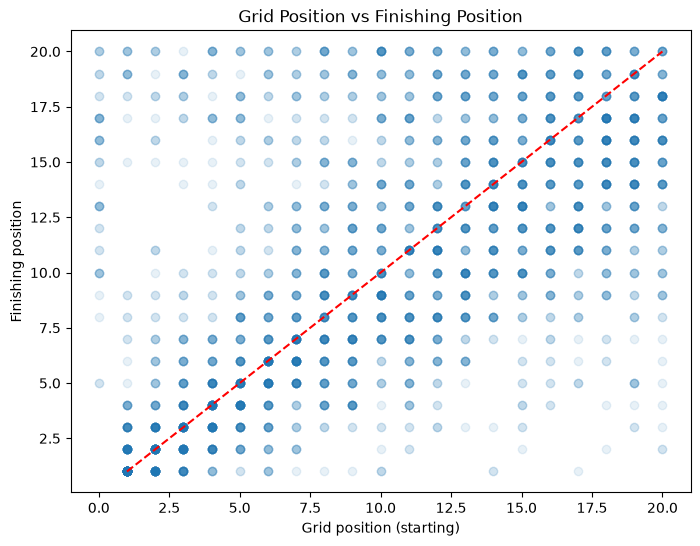

In [2]:
plt.figure(figsize=(8, 6))
plt.scatter(df["grid"], df["position"], alpha=0.1)
plt.xlabel("Grid position (starting)")
plt.ylabel("Finishing position")
plt.title("Grid Position vs Finishing Position")
plt.plot([1, 20], [1, 20], color="red", linestyle="--")  # reference line: grid = finish
plt.show()

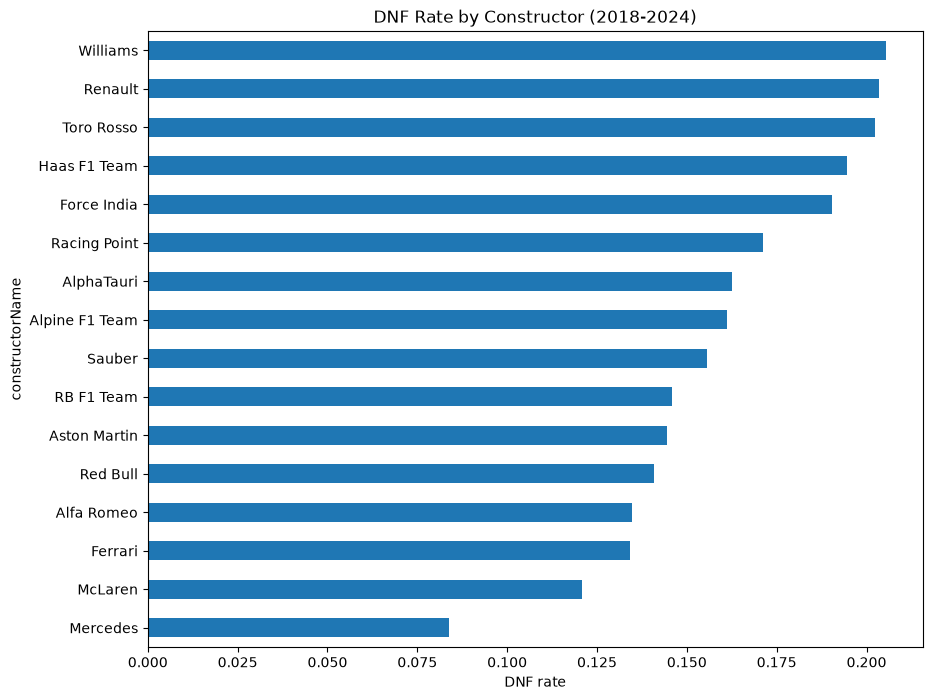

In [3]:
dnf_by_team = df.groupby("constructorName")["did_not_finish"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
dnf_by_team.plot(kind="barh")
plt.xlabel("DNF rate")
plt.title("DNF Rate by Constructor (2018-2024)")
plt.gca().invert_yaxis()  # highest DNF rate at the top
plt.show()

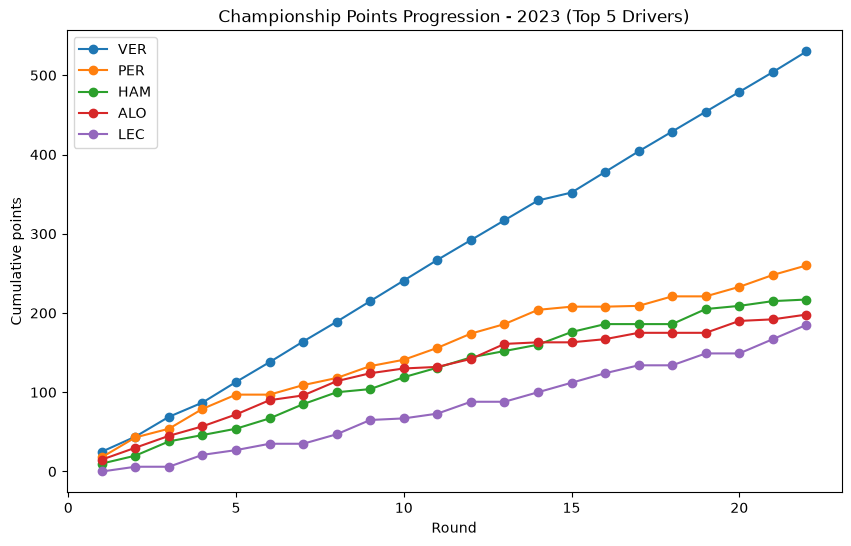

In [4]:
season_2023 = df[df["season"] == 2023].sort_values("round")

top_drivers = (
    season_2023.groupby("driverCode")["points"].sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plt.figure(figsize=(10, 6))
for driver in top_drivers:
    driver_data = season_2023[season_2023["driverCode"] == driver]
    cumulative_points = driver_data["points"].cumsum()
    plt.plot(driver_data["round"], cumulative_points, marker="o", label=driver)

plt.xlabel("Round")
plt.ylabel("Cumulative points")
plt.title("Championship Points Progression - 2023 (Top 5 Drivers)")
plt.legend()
plt.show()